# Optimizing EMCEE Fits!

In the "Finding_Interpolator" notebook, we figured out that the LinearNDInterpolator function will do with our mcmc model fitting!

After doing some initial tests in the same notebook, we also saw that the emcee package ran much faster than ucdmcmc but was getting seemingly worse fits....

## Things I wish to Try
- implenting a scale factor into the log likelihood function
- Tackling Discrete Parameters (clouds vs no clouds)
- Making a general model --> interpolation --> emcee --> plots, pipeline

In [1]:
import ucdmcmc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("/Users/epritchard/Research/")
import TAPS
import emcee
import scipy.interpolate
import corner



Welcome to the UCDMCMC spectral fitting code!
This code is designed to conduct both grid and MCMC fitting of spectral data of ultracool dwarfs
You are currently using version dated 2026.04.03

If you make use of this code for your research, please remember to cite our Zenodo DOI:
	10.5281/zenodo.16923762 (https://doi.org/10.5281/zenodo.16923762)
If you make use of any spectra or models in this toolkit, please remember to cite the original source.
Please report any errors are feature requests to our github page, http://www.github.com/aburgasser/ucdmcmc/


Currently running in error checking mode


Welcome to the Spex Prism Library Analysis Toolkit (SPLAT)!
You are currently using version 2025.12.26

If you make use of any features of this toolkit for your research, please remember to cite the SPLAT paper:

Burgasser et al. (2017, Astro. Soc. India Conf. Series 14, p. 7); Bibcode: 2017ASInC..14....7B

If you make use of any spectra or models in this toolkit, please remember to cite the

# Globals & Functions!

In [32]:
N_WALKERS = 24

def log_likelihood(theta, sp, interpolator):

    x = sp.wave.value
    y = sp.flux.value
    dy = sp.noise.value
    
    model = interpolator(theta)
    
    if not np.all(np.isfinite(model)):
        return -np.inf
    
    alpha = np.nansum(((y) * (model)) / (dy**2)) / np.nansum((model**2) / (dy**2), axis=-1)

    return np.nansum((-0.5) * (np.log(2*np.pi*dy**2) + ((y - (alpha * model)) / dy)**2), axis=-1)

def chain_plots(sampler, **kwargs):
    """
    Plot the histories for each walker in sampler.chain
    
    Parameters
    ----------
    chain: ndarray
        3D array given by sampler.flatchain, with shape (n_walkers, n_steps, n_params)
    kwargs: `.Line2D` properties, optional
        All keyword arguments are passed to `pyplot.plot`
    """
    
    enr_chain = sampler.chain[:,:,0]
    logg_chain = sampler.chain[:,:,1]
    teff_chain = sampler.chain[:,:,2]
    z_chain = sampler.chain[:,:,3]

    plt.figure(figsize=(8,6))
    plt.plot(enr_chain.T) 
    plt.xlabel('Step Number')
    plt.ylabel('enr')

    plt.figure(figsize=(8,6))
    plt.plot(logg_chain.T) 
    plt.xlabel('Step Number')
    plt.ylabel('logg')

    plt.figure(figsize=(8,6))
    plt.plot(teff_chain.T) 
    plt.xlabel('Step Number')
    plt.ylabel('teff')

    plt.figure(figsize=(8,6))
    plt.plot(z_chain.T) 
    plt.xlabel('Step Number')
    plt.ylabel('z')


def plot_steps(sampler,
            *,
            Nburn=200
            ):
    
    enr_steps = sampler.flatchain[Nburn*sampler.nwalkers:, 0]
    logg_steps = sampler.flatchain[Nburn*sampler.nwalkers:, 1]
    teff_steps = sampler.flatchain[Nburn*sampler.nwalkers:, 2]
    z_steps = sampler.flatchain[Nburn*sampler.nwalkers:, 3]

    corner.corner(np.array([enr_steps, logg_steps, teff_steps, z_steps]).T, 
                #   show_titles=True, 
                color="gray", 
                #   titles=("Slope [m]", "Intercept [b]"), 
                quantiles=[0.16, .5, .84], 
                )
    
def plot_fit(sampler, sp, interpolator):
    argmax = np.argmax(sampler.get_log_prob())
    bestfit_param = sampler.flatchain[argmax]
    # print(bestfit_param)

    fleep = interpolator(bestfit_param)

    alpha = np.nansum(((sp.flux.value) * (fleep)) / (sp.noise.value**2)) / np.nansum((fleep**2) / (sp.noise.value**2))

    # print(alpha)
    # print(alpha*fleep[0,:])
    # print(sp.flux.value)
    plt.Figure(figsize=(8,8))
    plt.plot(sp.wave.value, alpha*fleep[0,:], label="mcmc_fit", lw=3, alpha=0.5, c="#a636c2")
    plt.plot(sp.wave.value, sp.flux.value, label=sp.name, c="black")
    plt.legend()
    plt.show()

# Iteration 1: The most UCDMCMC adjacent

Below is the result of lots and lots of fiddling and testing so not so much of a storyline to follow this time

Essentially the cell below:
- Initializes the sand24 model set
- Initializes a sample 2mass object from SpeX (with preprocessing stuff)
- Finds the parameters needed for interpolation
- Initializes a callable, interpolated model grid
- Finds the closest gridpoint in the original model set
- Generates a tight normal distribution of initial parameters centered around the bestfit grid point
- 

Reading in sample spectrum for instrument SPEX-PRISM of source 2MASS J0559-1404

Best parameters:
	model = sand24
	enrich = -0.05
	logg = 6.0
	teff = 1200.0
	z = -0.15
	scale = 8.039652552251787e-20
	chis = 185493.93454087264
	radius = 0.12576134749093554
	dof = 390.0
	rchi = 475.6254731817247


<Figure size 640x480 with 0 Axes>

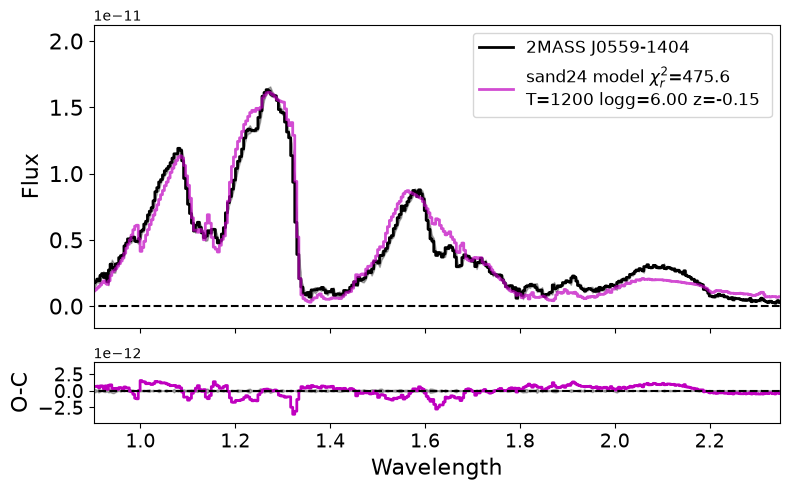


Best parameters:
	model = sand24
	enrich = -0.05
	logg = 6.0
	teff = 1200.0
	z = -0.15
	scale = 8.039652552251787e-20
	chis = 185493.93454087264
	radius = 0.12576134749093554
	dof = 390.0
	rchi = 475.6254731817247


<Figure size 640x480 with 0 Axes>

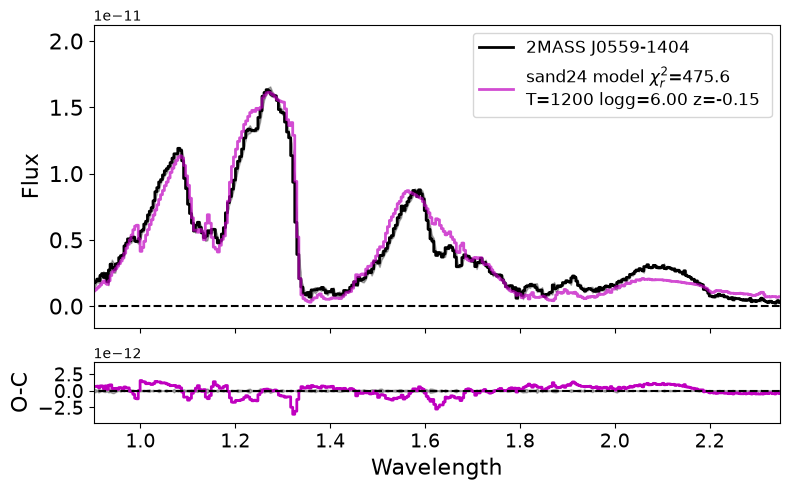

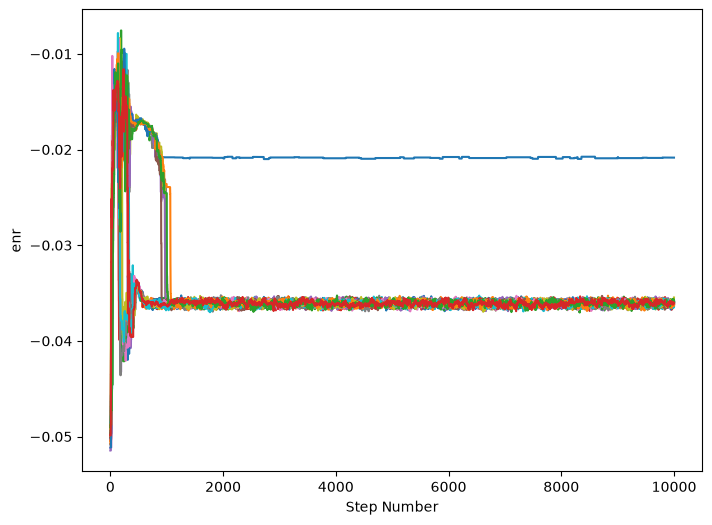

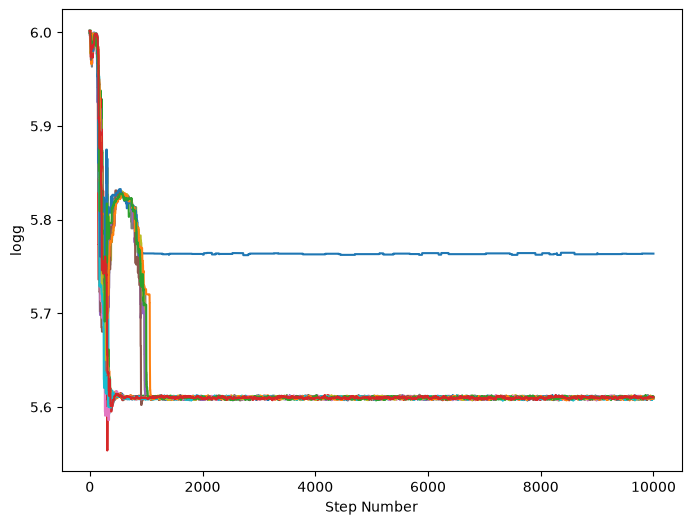

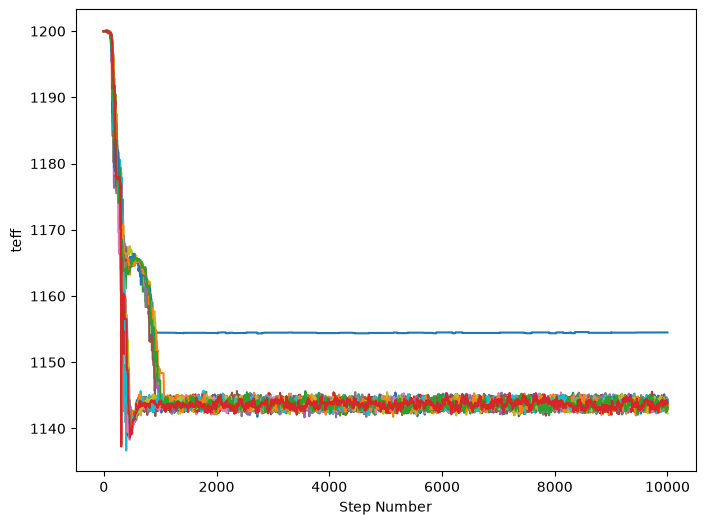

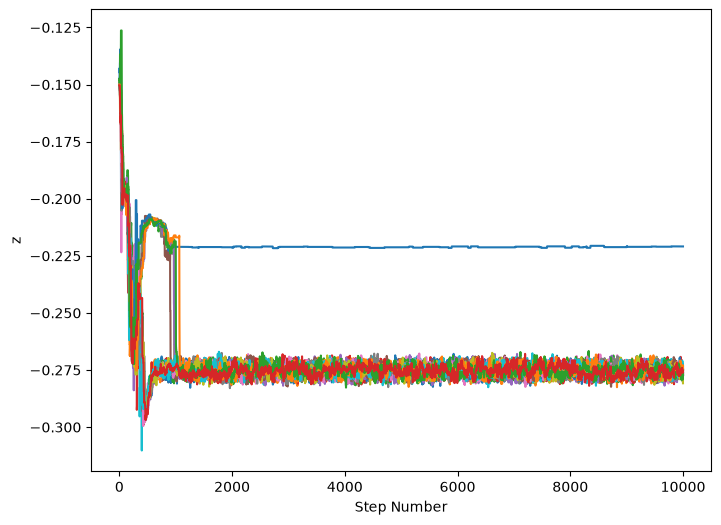

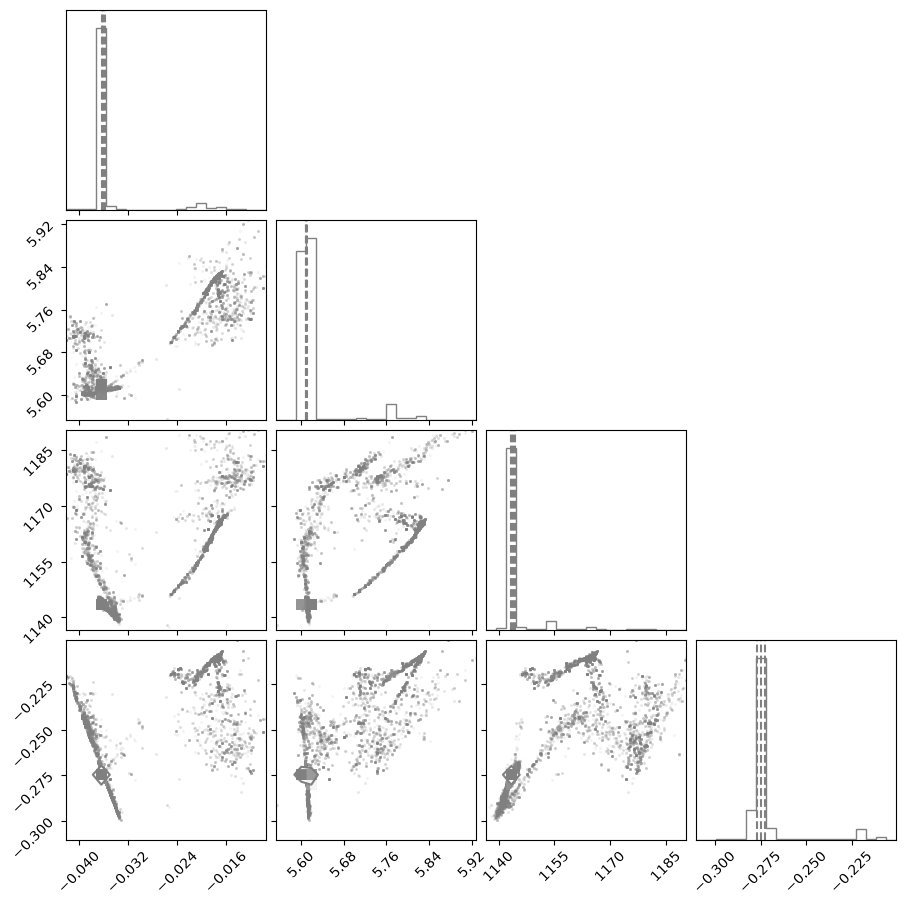

In [ ]:
models, wave = ucdmcmc.getModelSet(modelset='sand24',instrument='SPEX-PRISM')
wave_array = wave.value

# Some spectra preprocessing!
sp = ucdmcmc.getSample(instrument='SPEX-PRISM')
sp.trim([0.9,2.35])
sp.toWavelengths(wave)

columns = models.columns

inter_columns = []
for column in columns:
    if models[column].dtype == np.float64 and column != "flux":
        inter_columns.append(column)

param_points = models[inter_columns].to_numpy()
param_values = np.stack(models["flux"].to_numpy())
param_values = param_values # * scale

interp_nd = scipy.interpolate.LinearNDInterpolator(param_points, param_values, 
                                                    rescale=True
                                                   )


# This grabs the best fit grid point to the preproccessed spectra from above!
# the variable "par" is a dictionary with:
#   - The parameters of the best fit spectra
#   - other junk
# since we're gonna play around with the ipar of the walkers, we're gonna set all of them to start at the best grid point (just like how ucdmcmc walks)
par = ucdmcmc.fitGrid(sp, models)
initial_guesses = np.array([])

for column in inter_columns:
    new_column = np.random.normal(par[column], 0.001, N_WALKERS)
    initial_guesses = np.concatenate((initial_guesses, new_column))


initial_guesses = initial_guesses.reshape(N_WALKERS, len(inter_columns), order="F")


glorp = emcee.EnsembleSampler(N_WALKERS, 4, log_likelihood, moves=emcee.moves.StretchMove(a=0.5), args=(sp, interp_nd))
glorp.run_mcmc(initial_guesses, 10000)

chain_plots(glorp)
plot_steps(glorp)
# plot_fit(glorp, sp, interp_nd)

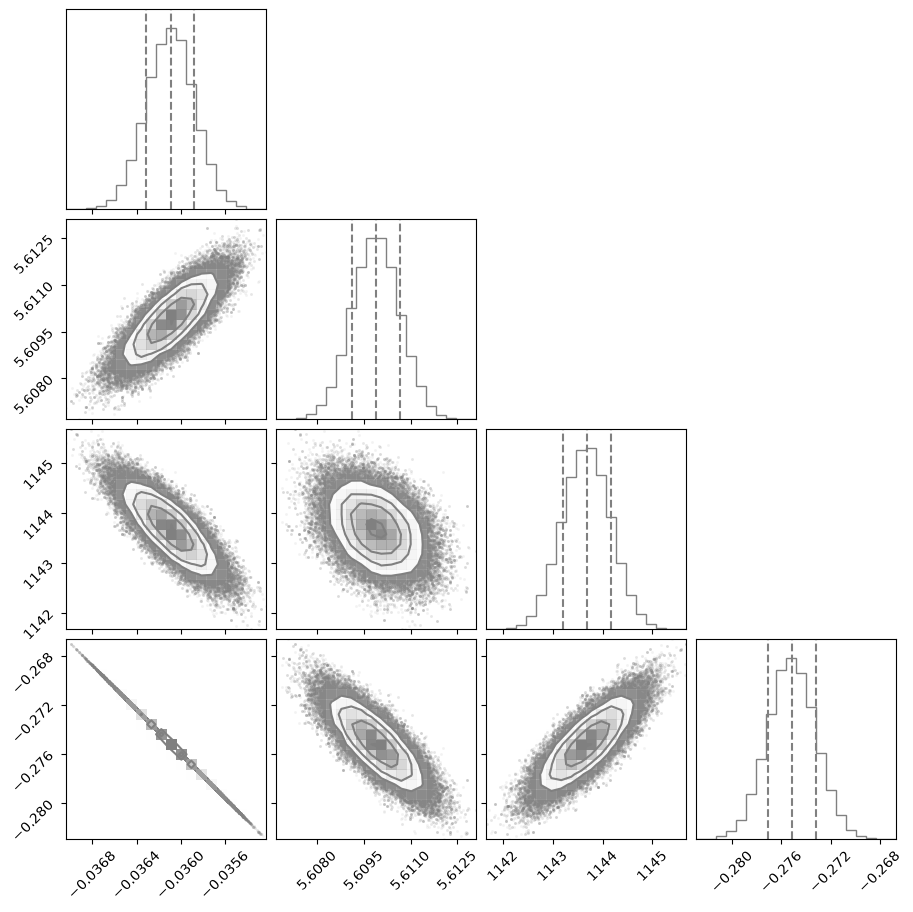

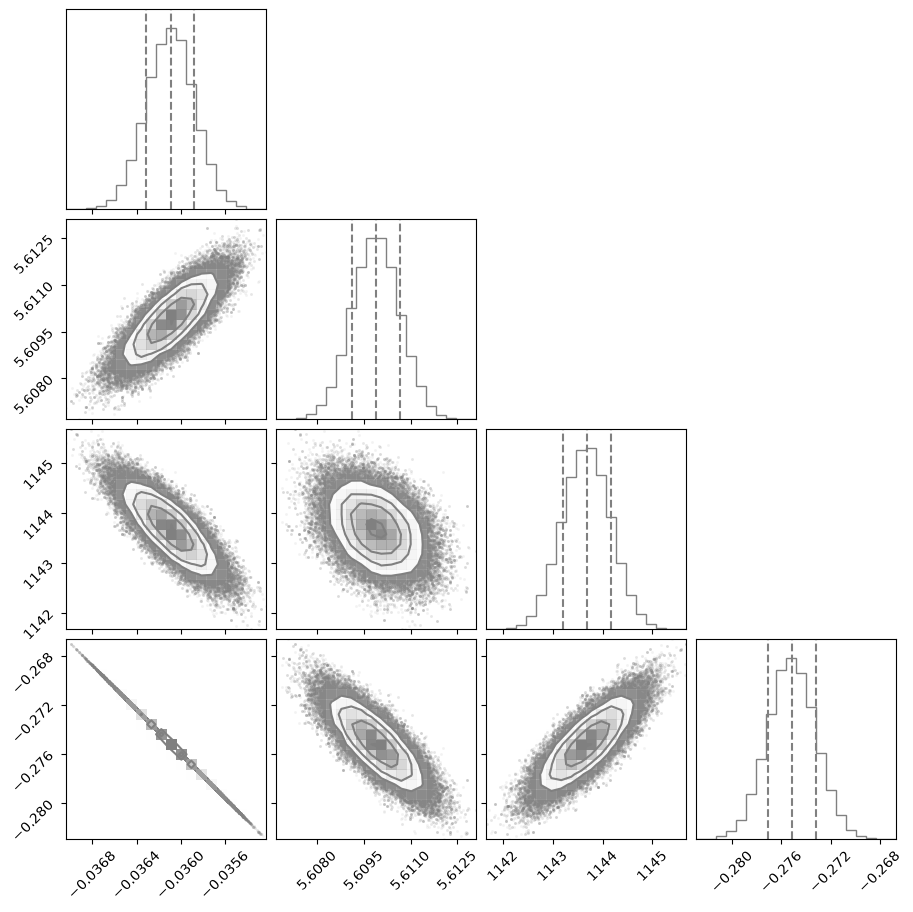

In [82]:
gleep = np.vstack((glorp.chain[:20, :, :], glorp.chain[21:, :, :]))
gleep.shape

enr_chain = gleep[:, :, 0]
logg_chain = gleep[:, :, 1]
teff_chain = gleep[:, :, 2]
z_chain = gleep[:, :, 3]

enr_flatten_chain = enr_chain.flatten(order="F")[23*1500:]
logg_flatten_chain = logg_chain.flatten(order="F")[23*1500:]
teff_flatten_chain = teff_chain.flatten(order="F")[23*1500:]
z_flatten_chain = z_chain.flatten(order="F")[23*1500:]

corner.corner(np.array([enr_flatten_chain, logg_flatten_chain, teff_flatten_chain, z_flatten_chain]).T, 
                #   show_titles=True, 
                color="gray", 
                #   titles=("Slope [m]", "Intercept [b]"), 
                quantiles=[0.16, .5, .84], 
                )

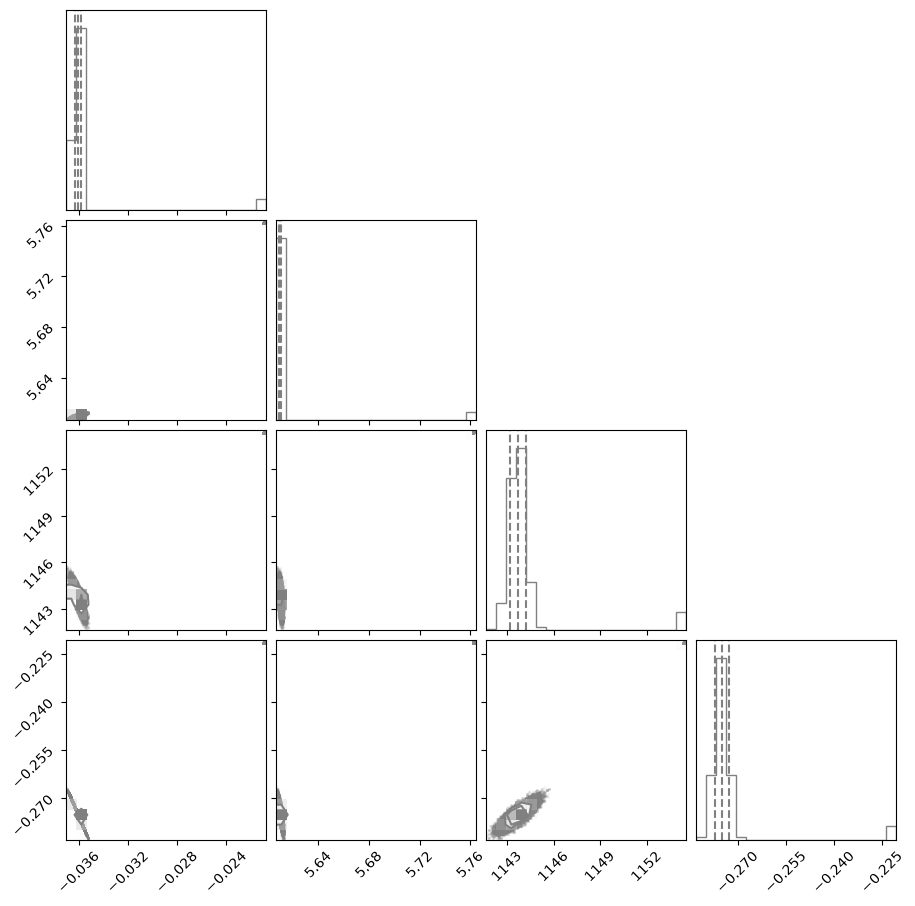

In [60]:
plot_steps(glorp, Nburn=1500)

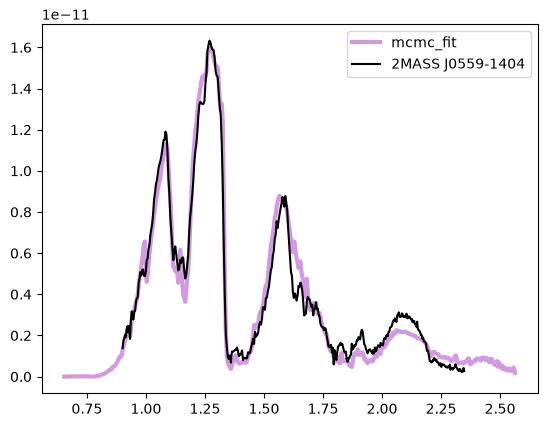

In [54]:
plot_fit(glorp, sp, interp_nd)

In [ ]:
test_grid_point = ucdmcmc.getGridModel(models, par, wave)
chi, scl, dof = ucdmcmc.compareSpec(test_grid_point.flux.value, sp.flux.value, sp.noise.value)
chi / dof

462.74543504498916

In [84]:
argmax = np.argmax(glorp.get_log_prob())
bestfit_param = glorp.flatchain[argmax]
fleep = interp_nd(bestfit_param)
alpha = np.nansum(((sp.flux.value) * (fleep)) / (sp.noise.value**2)) / np.nansum((fleep**2) / (sp.noise.value**2))


chi, scl, dof = ucdmcmc.compareSpec(alpha * fleep[0,:], sp.flux.value, sp.noise.value)
chi / dof

329.0319312280825

# Iteration 2: Randomized initial conditions!

Above the emcee pipeline had the emcee walkers all start around the bestfit grid point and walk from there but now I wanna see how the walkers react when placed randomly around the parameter space

I had issues before when doing this since if a walker is placed out of the availible grid, many won't be able to walk back into the grid and never move! 

I plan to fix this during initialization by having a check that tests if the point is real--if not, then the point will re-initialize until it finds a real point to start at. 

In [ ]:
models, wave = ucdmcmc.getModelSet(modelset='sand24',instrument='SPEX-PRISM')
wave_array = wave.value

# Some spectra preprocessing!
sp = ucdmcmc.getSample(instrument='SPEX-PRISM')
sp.trim([0.9,2.35])
sp.toWavelengths(wave)

# This grabs the best fit grid point to the preproccessed spectra from above!
# the variable "par" is a dictionary with:
#   - The parameters of the best fit spectra
#   - The optimal scale factor 

# par = ucdmcmc.fitGrid(sp, models) # dont need this if I use alpha in log L
# scale = par["scale"]

columns = models.columns

inter_columns = []
for column in columns:
    if models[column].dtype == np.float64 and column != "flux":
        inter_columns.append(column)

param_points = models[inter_columns].to_numpy()
param_values = np.stack(models["flux"].to_numpy())
param_values = param_values # * scale

interp_nd = scipy.interpolate.LinearNDInterpolator(param_points, param_values, 
                                                    rescale=True
                                                   )


ipar = np.zeros([N_WALKERS])
for column in inter_columns:
    new_row = np.random.uniform(low=np.nanmin(models[column]), high=np.nanmax(models[column]), size=N_WALKERS)
    ipar = np.vstack([ipar, new_row])

initial_guesses = ipar[1:, :]


glorp = emcee.EnsembleSampler(N_WALKERS, 4, log_likelihood, args=(sp.flux.value, sp.noise.value, interp_nd))
glorp.run_mcmc(initial_guesses.T, 10000, a=)

chain_plots(glorp)

Reading in sample spectrum for instrument SPEX-PRISM of source 2MASS J0559-1404


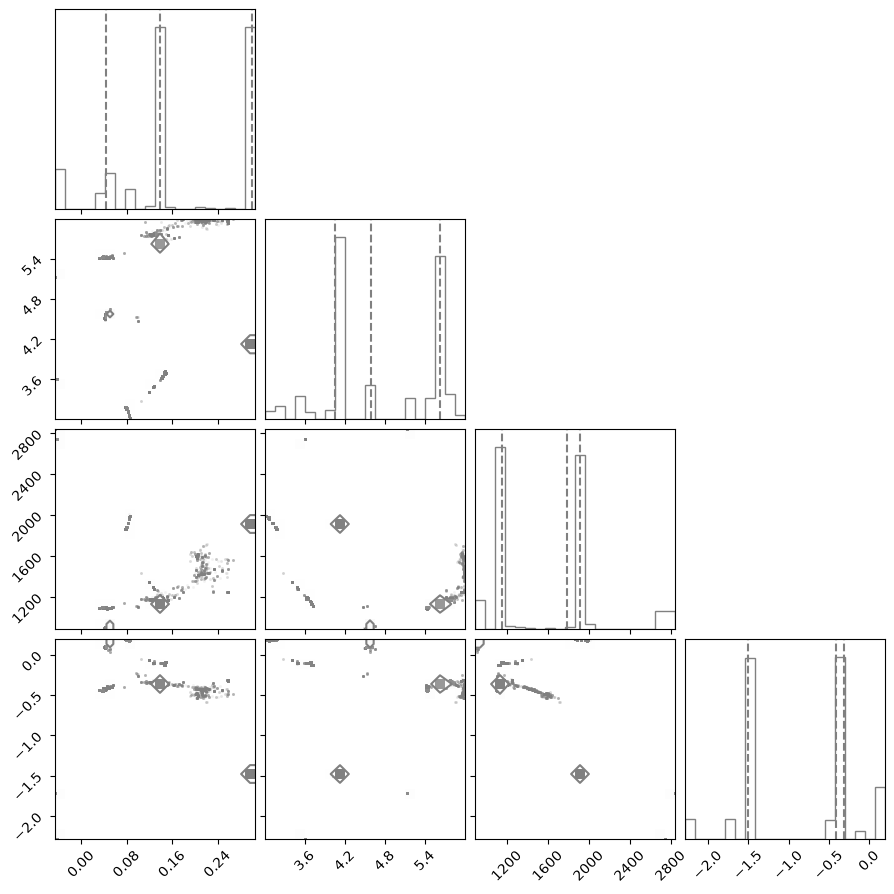

In [58]:
plot_steps(glorp)

[ 3.83819957e-02  5.43364508e+00  1.09981288e+03 -4.42959144e-01]
1.277069841284707e-19
[7.65730128e-16 1.67057791e-15 1.96141203e-15 2.30199404e-15
 2.70465659e-15 3.16598130e-15 3.69206931e-15 4.28392172e-15
 4.91114086e-15 5.63226393e-15 6.46208686e-15 7.27668869e-15
 8.10194083e-15 8.86862174e-15 9.41480296e-15 9.68786670e-15
 9.65291120e-15 9.39459562e-15 9.03890352e-15 8.84737671e-15
 8.98230432e-15 9.33279507e-15 1.01411215e-14 1.12854066e-14
 1.22647256e-14 1.30431174e-14 1.38682527e-14 1.49794768e-14
 1.60962076e-14 1.68366086e-14 1.74804065e-14 1.82156867e-14
 1.89601013e-14 1.95577310e-14 1.99009595e-14 2.02589526e-14
 2.04491364e-14 2.03400303e-14 2.01402708e-14 1.94627609e-14
 1.84839495e-14 1.71251348e-14 1.54464095e-14 1.31887887e-14
 1.03840929e-14 7.77309845e-15 5.27935216e-15 3.28771253e-15
 1.72870120e-15 5.94815941e-16 1.23693339e-16 6.16640006e-17
 2.67849574e-16 1.20153587e-15 3.20195171e-15 4.75361064e-15
 8.51649355e-15 1.47742896e-14 2.05393050e-14 2.68597947e-

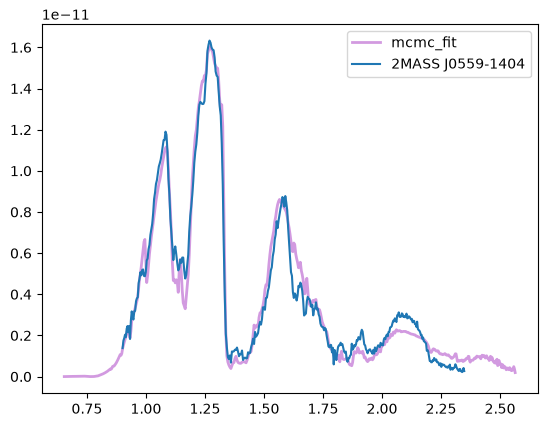

In [59]:
plot_fit(glorp, sp, interp_nd)

# Walkers are converging at different spots....

That is a bit interesting...

I am not sure if thats a real effect or from how my code is written. Out of curiosity I want to see how the log likelihood looks across the parameter space...

We'll do this by simply initilizing a grid and seeing if the space is simply multi-modal!

In [10]:
model = interp_nd(0.2, 4.0, 2500, -1.0)
model.shape

(563,)

In [ ]:
def log_likelihood(theta, sp, interpolator):

    x = sp.wave.value
    y = sp.flux.value
    dy = sp.noise.value
    
    model = interpolator(np.atleast_2d(theta))
    
    # if not np.all(np.isfinite(model), axis=-1):
    #     return -np.inf

    finite_mask = np.all(np.isfinite(model), axis=-1)
    
    alpha = np.nansum(((y) * (model)) / (dy**2), axis=-1) / np.nansum((model**2) / (dy**2), axis=-1)

    chi = (y - (alpha[..., None] * model)) / dy

    output = np.nansum((-0.5) * (np.log(2*np.pi*dy**2) + chi**2), axis=-1)

    output = np.where(finite_mask, output, -np.inf)

    return output[0] if output.size == 1 else output

range_dict = {}
for column in inter_columns:
    range_dict[column] = (np.nanmin(models[column]), np.nanmax(models[column]))

N_points = 500
enr_range =  np.linspace(range_dict["enrich"][0], range_dict["enrich"][1], 25) 
logg_range =  np.linspace(range_dict["logg"][0], range_dict["logg"][1], 50) 
teff_range =  np.linspace(range_dict["teff"][0], range_dict["teff"][1], 100) 
z_range =  np.linspace(range_dict["z"][0], range_dict["z"][1], 100) 

theta_grid = np.array(np.meshgrid(enr_range, logg_range, teff_range, z_range))
theta_grid.shape

posterior_grid = log_likelihood(theta_grid, sp, interp_nd)



corner.corner(posterior_grid.T, 
                #   show_titles=True, 
                color="gray", 
                #   titles=("Slope [m]", "Intercept [b]"), 
                quantiles=[0.16, .5, .84], 
                )



(4, 50, 25, 100, 100)

In [ ]:
from emcee import ptsampler